1. Load and understand dataset (columns, types, target
variable).

In [30]:
import pandas as pd


In [31]:
df = pd.read_excel("Pharmaceutical Supply Chain Optimization.xlsx")
df

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy
0,Metformin,7750,4753,Monthly
1,Lisinopril,5136,9965,Quarterly
2,Metformin,3183,2933,Monthly
3,Insulin,2332,3927,Monthly
4,Atorvastatin,3522,6812,Monthly
...,...,...,...,...
99995,Metformin,7635,7794,Weekly
99996,Atorvastatin,8438,7308,Monthly
99997,Metformin,4950,3445,Quarterly
99998,Atorvastatin,4672,5278,Monthly


In [32]:
df.columns

Index(['Drug', 'Demand_Forecast', 'Optimal_Stock_Level',
       'Restocking_Strategy'],
      dtype='object')

In [33]:
df.dtypes

Drug                   object
Demand_Forecast         int64
Optimal_Stock_Level     int64
Restocking_Strategy    object
dtype: object

In [34]:
df.describe()

,Demand_Forecast,Optimal_Stock_Level
count,100000.000000,100000.000000
mean,5489.372180,6270.155320
std,2597.544993,2744.393068
min,1000.000000,1500.000000
25%,3243.000000,3899.750000
50%,5487.000000,6278.000000
75%,7738.000000,8660.000000
max,9999.000000,10999.000000


In [35]:
df.shape

(100000, 4)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   Drug                 100000 non-null  object
 1   Demand_Forecast      100000 non-null  int64 
 2   Optimal_Stock_Level  100000 non-null  int64 
 3   Restocking_Strategy  100000 non-null  object
dtypes: int64(2), object(2)
memory usage: 3.1+ MB


2. Handle missing values and outliers

In [37]:
df.isnull().sum()

Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(5)

In [39]:
df.drop_duplicates(inplace=True)

In [40]:
q1 = df["Demand_Forecast"].quantile(0.25)
q3 = df["Demand_Forecast"].quantile(0.75)
print(f"q1: {q1}")
print(f"q3: {q3}")

q1: 3243.0
q3: 7738.0


In [41]:
IQR = q3 - q1
print(IQR)

4495.0


In [42]:
lower = q1 - 1.5 * IQR
upper = q3 + 1.5 * IQR

In [43]:
outliers = df[(df["Demand_Forecast"] < lower) | (df["Demand_Forecast"] > upper)]
print(outliers)

Empty DataFrame
Columns: [Drug, Demand_Forecast, Optimal_Stock_Level, Restocking_Strategy]
Index: []


In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

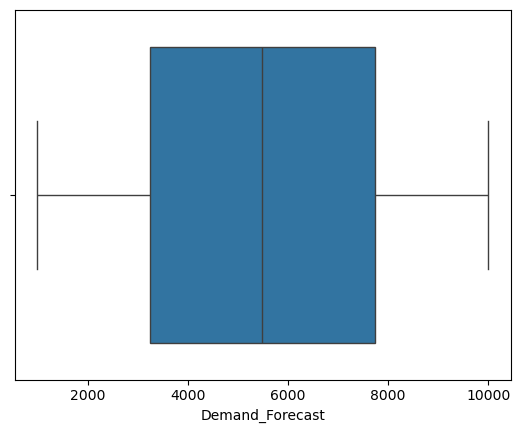

In [45]:
sns.boxplot(x=df["Demand_Forecast"])
plt.show()

Feature engineering (e.g., dosage to volume ratio,
temperature bands).


In [46]:
df['Demand_to_Stock_Ratio'] = df['Demand_Forecast'] / (df['Optimal_Stock_Level'] + 1)


In [47]:
df.head()

,Drug,Demand_Forecast,Optimal_Stock_Level,Restocking_Strategy,Demand_to_Stock_Ratio
0,Metformin,7750,4753,Monthly,1.630206
1,Lisinopril,5136,9965,Quarterly,0.515352
2,Metformin,3183,2933,Monthly,1.084867
3,Insulin,2332,3927,Monthly,0.593686
4,Atorvastatin,3522,6812,Monthly,0.516953


In [48]:
df_encoded = pd.get_dummies(df, columns=['Drug', 'Restocking_Strategy'], drop_first=True)

In [49]:
df_encoded

,Demand_Forecast,Optimal_Stock_Level,Demand_to_Stock_Ratio,Drug_Insulin,Drug_Lisinopril,Drug_Metformin,Restocking_Strategy_Quarterly,Restocking_Strategy_Weekly
0,7750,4753,1.630206,False,False,True,False,False
1,5136,9965,0.515352,False,True,False,True,False
2,3183,2933,1.084867,False,False,True,False,False
3,2332,3927,0.593686,True,False,False,False,False
4,3522,6812,0.516953,False,False,False,False,False
...,...,...,...,...,...,...,...,...
99995,7635,7794,0.979474,False,False,True,False,True
99996,8438,7308,1.154467,False,False,False,False,False
99997,4950,3445,1.436448,False,False,True,True,False
99998,4672,5278,0.885016,False,False,False,False,False


In [53]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df_encoded)
scaled_df = pd.DataFrame(X_scaled, columns=df_encoded.columns)

In [55]:
scaled_df

,Demand_Forecast,Optimal_Stock_Level,Demand_to_Stock_Ratio,Drug_Insulin,Drug_Lisinopril,Drug_Metformin,Restocking_Strategy_Quarterly,Restocking_Strategy_Weekly
0,0.750083,0.342457,0.235110,0.0,0.0,1.0,0.0,0.0
1,0.459607,0.891146,0.064696,0.0,1.0,0.0,1.0,0.0
2,0.242583,0.150858,0.151751,0.0,0.0,1.0,0.0,0.0
3,0.148016,0.255501,0.076670,1.0,0.0,0.0,0.0,0.0
4,0.280253,0.559217,0.064941,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
99990,0.737304,0.662596,0.135641,0.0,0.0,1.0,0.0,1.0
99991,0.826536,0.611433,0.162390,0.0,0.0,0.0,0.0,0.0
99992,0.438938,0.204758,0.205493,0.0,0.0,1.0,1.0,0.0
99993,0.408045,0.397726,0.121202,0.0,0.0,0.0,0.0,0.0


In [56]:
X = scaled_df.drop('Optimal_Stock_Level', axis=1)
y = scaled_df['Optimal_Stock_Level']


In [62]:
from sklearn.linear_model import LinearRegression


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [67]:
y_pred = model.predict(X_test)